[Level 2] total usable rows: 265
[Level 2] models seen: 8 -> ['google_gemma-3-12b-it', 'google_gemma-3-4b-it', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-32B', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-8B']
[Level 2] self-play present for: ['Qwen_Qwen3-32B', 'google_gemma-3-4b-it', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-8B', 'google_gemma-3-12b-it', 'nvidia_AceReason-Nemotron-14B']
[Level 2] selected 'complete-mix' MODELS: ['google_gemma-3-12b-it', 'google_gemma-3-4b-it', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-32B', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-8B']


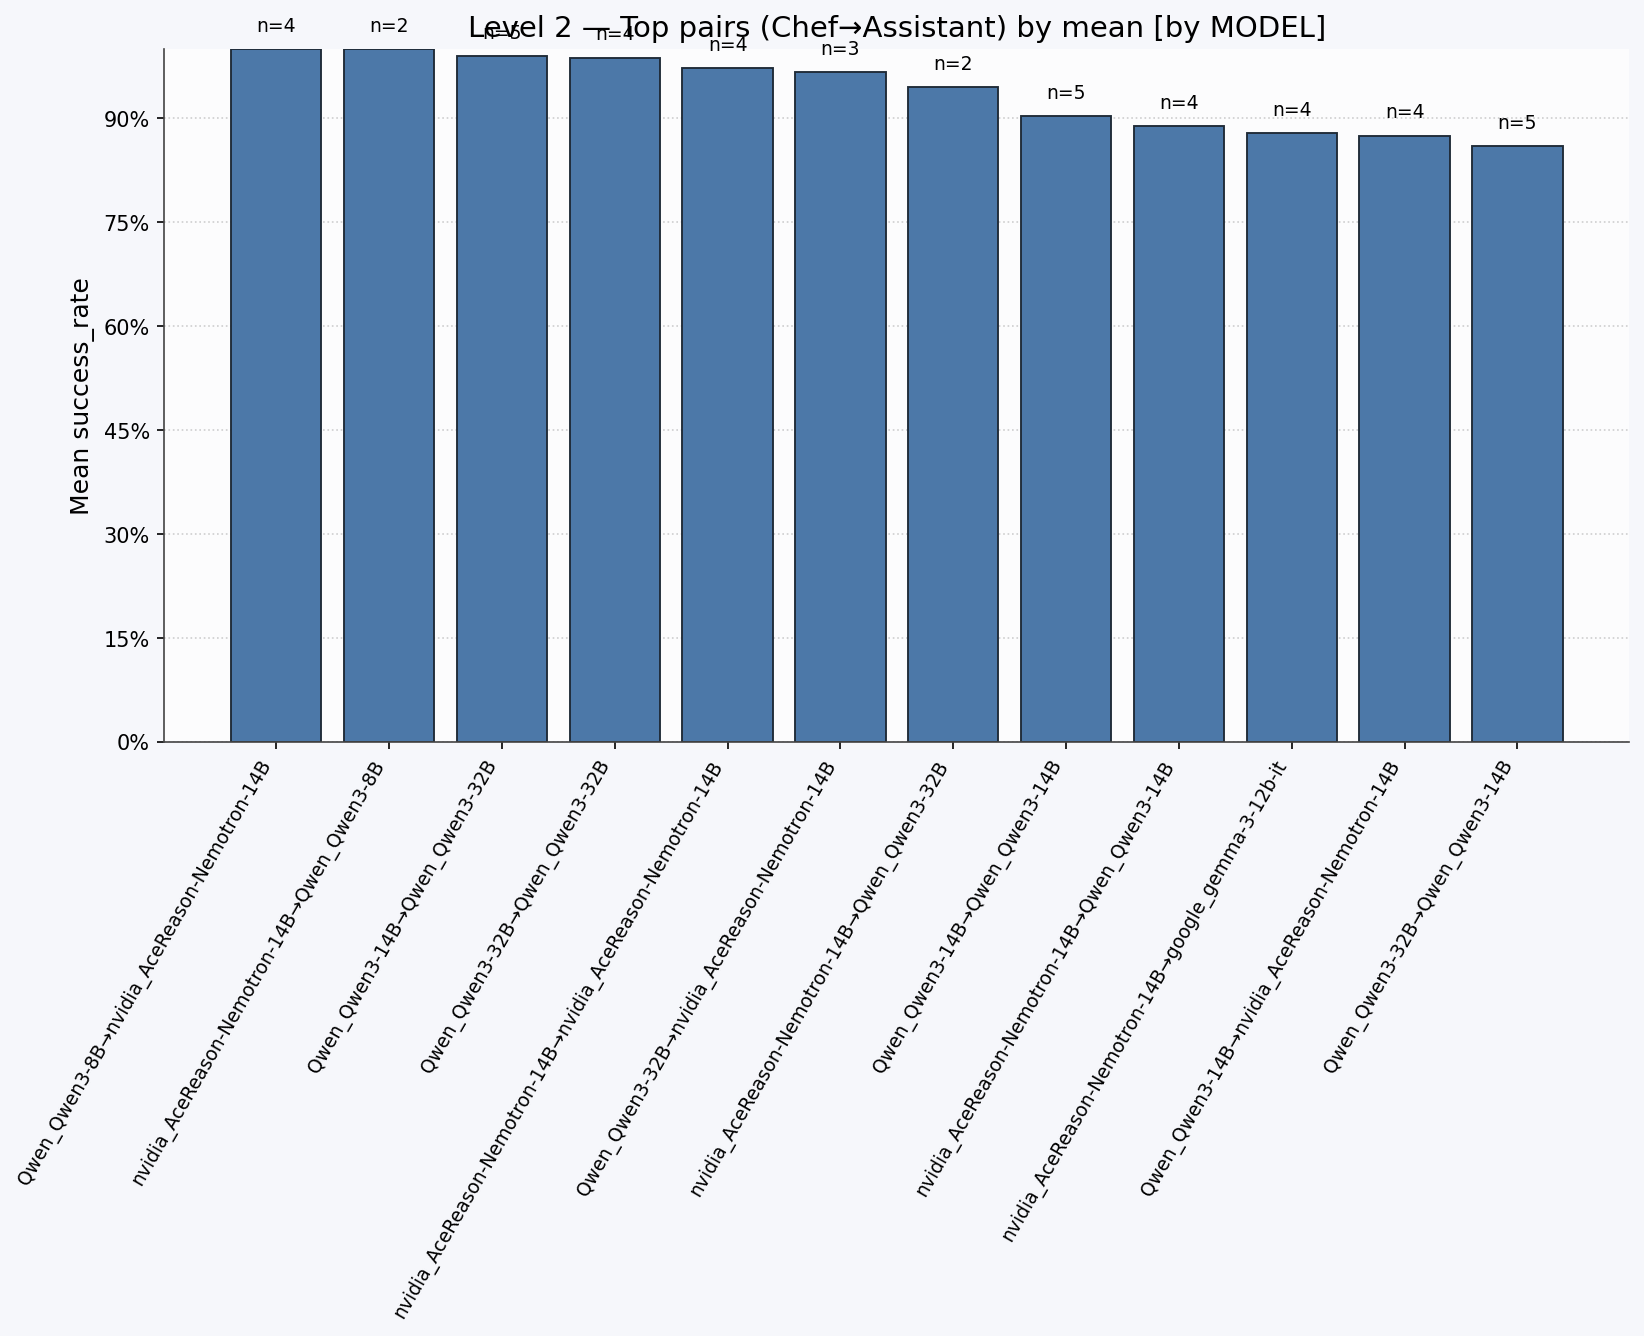

Saved -> ./plots/level_2__top_pairs_by-model_with_self.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_2584/161476914.py:528: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = plt.cm.get_cmap("Blues", max(10, len(series_Chef_plot)))
/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_2584/161476914.py:550: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_A = plt.cm.get_cmap("Blues", max(10, len(series_Asst_plot)))


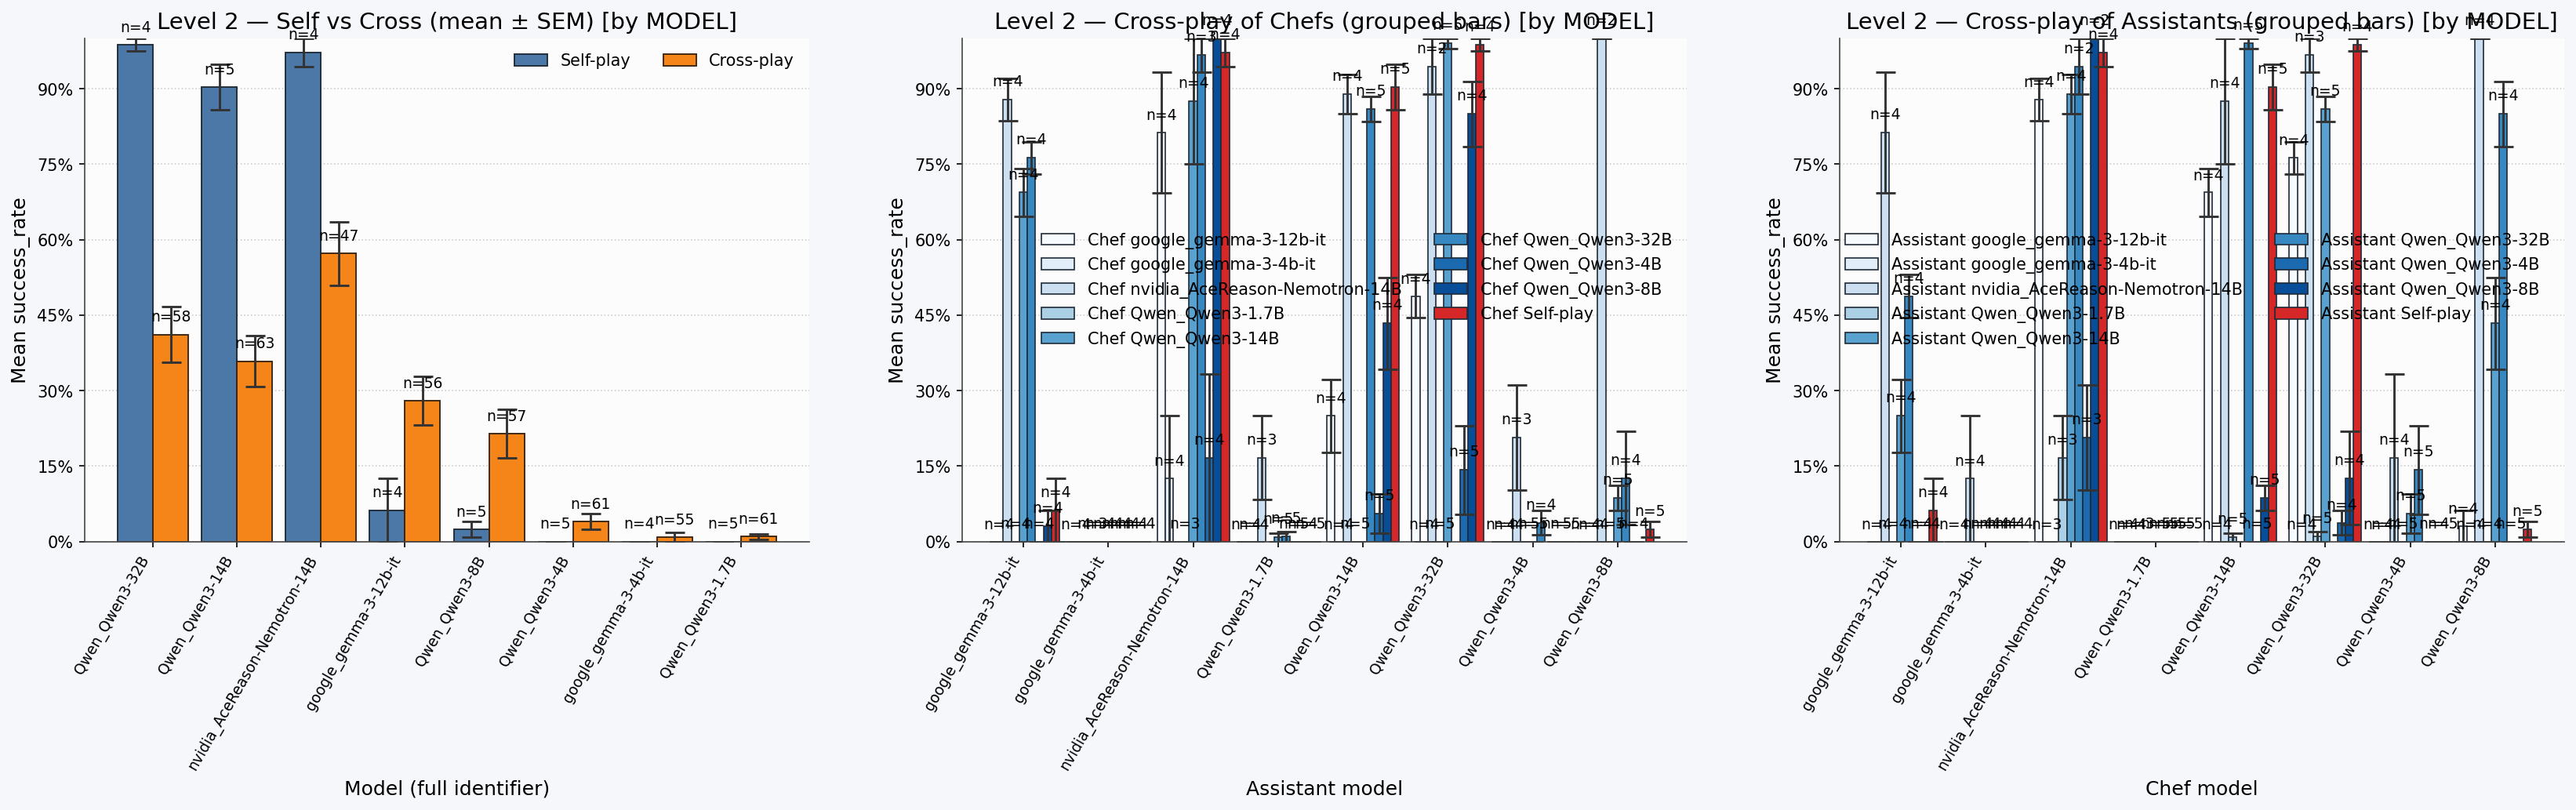

Saved -> ./plots/level_2__composite_bars_by-model.png
[Level 2] Final models used (complete-mix): 8
  Chef models: ['google_gemma-3-12b-it', 'google_gemma-3-4b-it', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-32B', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-8B']
  Assistant models: ['google_gemma-3-12b-it', 'google_gemma-3-4b-it', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-32B', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-8B']


In [12]:
def order_models_by_size_and_prettify(models, *, descending=True):
    """
    Parameters
    ----------
    models : Iterable[str]
        Raw model identifiers from the CSV (e.g., 'Qwen_Qwen3-8B', 'google_gemma-3-4b-it').
    descending : bool
        If True, larger models first.

    Returns
    -------
    sorted_models : list[str]
        Same identifiers, sorted by parsed size (B). Unknown sizes go to the end.
    pretty_map : dict[str, str]
        Mapping raw_id -> human-friendly name (for axes & legends).
    size_map : dict[str, float]
        Parsed sizes in billions (float('inf') if size not found).
    """
    import re
    def _extract_size_b(s: str) -> float:
        # take the right-most "<number>(.number)?[bB]" as the size in billions
        m = list(re.finditer(r'(\d+(?:\.\d+)?)\s*[bB](?![a-zA-Z])', s))
        return float(m[-1].group(1)) if m else float('inf')

    def _pretty(s: str) -> str:
        low = s.lower()

        # Qwen family
        if 'qwen3' in low:
            m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
            return f"Qwen3 {m.group(1)}B" if m else "Qwen3"

        # Gemma 3 family
        if 'gemma-3' in low:
            m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
            sz = f"{m.group(1)}B" if m else ""
            return f"Gemma 3 {sz} (Instruct)".strip()

        # Nemotron / AceReason family
        if 'nemotron' in low:
            m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
            sz = f"{m.group(1)}B" if m else ""
            tag = "AceReason" if 'acereason' in low else ""
            return f"Nemotron {sz} {f'({tag})' if tag else ''}".strip()

        # Generic fallback: title-case the second half, keep size if present
        m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
        sz = f"{m.group(1)}B" if m else ""
        fam = s.split('_', 1)[-1] if '_' in s else s
        fam = re.sub(r'[-_](it|instruct|chat)$', '', fam, flags=re.I)
        fam = fam.replace('-', ' ').replace('_', ' ').title()
        fam = fam.strip()
        return (f"{fam} {sz}").strip()

    sizes = {m: _extract_size_b(m) for m in models}
    sorted_models = sorted(
        models,
        key=lambda m: (sizes[m], m.lower()),
        reverse=bool(descending)
    )
    pretty_map = {m: _pretty(m) for m in sorted_models}
    return sorted_models, pretty_map, sizes


# NumPy + matplotlib (no pandas)
# Jupyter-friendly Level-2 analysis grouped by *MODEL NAME* (not size)
# Role mapping (agreed):
#   agent_0 = Chef (first model in 'model' string)
#   agent_1 = Assistant (second model in 'model' string)

import os
import csv
import re
import math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

# =================== Config (adjust here if needed) ===================
INPUT_CANDIDATES = [
    "statistics_data_cross-play-data.csv",            # local alt
]
OUT_DIR = "./plots"
ONLY_LEVEL = 2            # numeric level filter
SUCCESS_COL = 3          # which column is success_rate (default: last column)

# Mutual-coverage set ("complete-mix"): for every A,B in the set, both A→B and B→A exist
REQUIRE_BIDIRECTIONAL = True
REQUIRE_SELF_FOR_SELECTION = False  # self-play not required to include a model in the set

# Plot behavior / style
VERBOSE_SUMMARY = True
ANNOTATE_COUNTS = True
TOP_PAIRS_COUNT = 12
INCLUDE_SELF_IN_TOP = True
COLORS = {"self": "#4C78A8", "cross": "#F58518"}
SELFPLAY_RED = "#D62728"

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

# =================== Helpers ===================
def find_path(cands):
    for p in cands:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV at any of: {cands}")

# Expect pattern like "Vendor_ModelA-Vsize_Vendor_ModelB-Vsize"
def parse_pair(model_str):
    parts = model_str.split("_")
    if len(parts) >= 4:
        a = parts[0] + "_" + parts[1]  # Chef (agent_0)
        b = parts[2] + "_" + parts[3]  # Assistant (agent_1)
    else:
        mid = len(parts) // 2
        a = "_".join(parts[:mid])
        b = "_".join(parts[mid:])
    return a, b

# For model-name sorting (lexicographic, case-insensitive)
def model_key(name: str):
    return (name.split("_")[0].lower(), name.lower())

# Percent SEM

def sem(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float("nan")
    return float(np.std(x, ddof=1) / np.sqrt(n))

# Cosmetics

def sanitize_token(s):
    import re as _re
    return _re.sub(r"[^A-Za-z0-9._-]+", "_", str(s))

def polish_axes(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor("#FCFCFD")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

def format_as_percent_if_applicable(ax, ymax_est):
    # If success_rate appears to be in [0,1], display as %
    if np.isfinite(ymax_est) and ymax_est <= 1.05:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*100:.0f}%"))
        ax.set_ylim(0, max(1.0, ymax_est))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

def show_and_save(fig, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("Saved ->", path)

# Grouped-bars utility

def _safe_color_from_map(cmap, i, k):
    if k <= 1:
        t = 0.5
    else:
        t = i / (k - 1)
    return cmap(t)

def plot_grouped_bars(ax, x_labels, series_keys, mean_map, sem_map, n_map,
                      color_map, label_prefix, error_kw, color_for=None,
                      annotate_counts=True):
    x = np.arange(len(x_labels), dtype=float)
    k = max(1, len(series_keys))
    width = min(0.85 / k, 0.28)

    ymax_est = 0.0
    for i, sk in enumerate(series_keys):
        heights = [mean_map[sk].get(lbl, float("nan")) for lbl in x_labels]
        errors  = [sem_map[sk].get(lbl,  float("nan")) for lbl in x_labels]
        counts  = [n_map[sk].get(lbl,    0)             for lbl in x_labels]

        pos = x + (i - (k - 1) / 2.0) * width
        color = color_for(i, sk) if color_for is not None else _safe_color_from_map(color_map, i, k)

        bars = ax.bar(pos, heights, width,
                      yerr=errors,
                      label=f"{label_prefix} {sk}",
                      color=color,
                      edgecolor="#1f2a36",
                      linewidth=0.8,
                      error_kw=error_kw)

        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin if ymax > ymin else 1.0
        for rect, h, n, e in zip(bars, heights, counts, errors):
            if not np.isfinite(h):
                continue
            ymax_est = max(ymax_est, float(h) + (e if np.isfinite(e) else 0.0))
            if annotate_counts:
                ax.text(rect.get_x() + rect.get_width()/2.0,
                        rect.get_height() + 0.02 * yrange,
                        f"n={n}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x, x_labels, rotation=60, ha="right")
    return ymax_est

# =================== Read CSV (positional schema) ===================

def is_level_two(v):
    s = str(v).strip().lower()
    return s == "2" or s == "2.0" or bool(re.search(r"(?:^|[^0-9])2(?:\.0+)?(?:[^0-9]|$)", s))

csv_path = find_path(INPUT_CANDIDATES)

rows_level2 = []  # (chef_model, asst_model, success_rate)
pairs_present_dir = set()
models_all = set()
self_present = defaultdict(bool)

with open(csv_path, newline="", encoding="utf-8") as f:
    rd = csv.reader(f)
    header = next(rd, None)  # skip header (contains non-standard tokens)
    for row in rd:
        if not row or len(row) < 4:
            continue
        model_str = row[0].strip()
        level_raw = row[2].strip()  # numeric level lives here in this file
        if not is_level_two(level_raw):
            continue

        # success rate from configured column (default: last column)
        sr = None
        try:
            sr = float(row[SUCCESS_COL])
        except Exception:
            # last-numeric fallback
            for tok in reversed(row):
                try:
                    sr = float(tok)
                    break
                except Exception:
                    continue
        if sr is None:
            continue

        a_model, b_model = parse_pair(model_str)  # full model identifiers (include sizes)
        if not a_model or not b_model:
            continue

        models_all.update([a_model, b_model])
        pairs_present_dir.add((a_model, b_model))
        if a_model == b_model:
            self_present[a_model] = True

        rows_level2.append((a_model, b_model, sr))

if not models_all:
    raise RuntimeError("No Level 2 rows found (by-model parsing). Check CSV format and SUCCESS_COL.")

if VERBOSE_SUMMARY:
    print(f"[Level 2] total usable rows: {len(rows_level2)}")
    print(f"[Level 2] models seen: {len(models_all)} ->", sorted(models_all, key=model_key))
    print(f"[Level 2] self-play present for: {[m for m,v in self_present.items() if v]}")

# =================== Clique (complete-mix) over MODELS ===================

def build_mutual_graph(pairs_present, models):
    neighbors = {m: set() for m in models}
    for a in models:
        for b in models:
            if a == b: 
                continue
            if (a, b) in pairs_present and (b, a) in pairs_present:
                neighbors[a].add(b)
    return neighbors


def is_clique(nodes, neighbors, require_self=False, self_present=None):
    nodes = list(nodes)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            a, b = nodes[i], nodes[j]
            if b not in neighbors.get(a, set()) or a not in neighbors.get(b, set()):
                return False
    if require_self and self_present is not None:
        for m in nodes:
            if not self_present.get(m, False):
                return False
    return True


def largest_complete_mix_set(neighbors, require_self=False, self_present=None):
    from itertools import combinations
    models = sorted(neighbors.keys(), key=model_key)
    n = len(models)
    for k in range(n, 0, -1):
        found = []
        for combo in combinations(models, k):
            if is_clique(combo, neighbors, require_self=require_self, self_present=self_present):
                found.append(list(combo))
        if found:
            # Prefer combos with more self-play present, then lexicographic
            if not require_self and self_present is not None:
                found.sort(key=lambda lst: (sum(1 for m in lst if self_present.get(m, False)),
                                            [m.lower() for m in lst]), reverse=True)
            return found[0]
    return []

neighbors = build_mutual_graph(pairs_present_dir, models_all)
selected_models = largest_complete_mix_set(neighbors,
                                           require_self=REQUIRE_SELF_FOR_SELECTION,
                                           self_present=self_present)
if not selected_models:
    selected_models = sorted(models_all, key=model_key)  # fallback

if VERBOSE_SUMMARY:
    print(f"[Level 2] selected 'complete-mix' MODELS: {selected_models}")

# =================== Aggregate restricted to selected models ===================
level_key = "2"  # string key for dicts
buckets_by_model = defaultdict(list)  # (level, model, 'self'/'cross') -> list[success_rate]
cross_matrix = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
chef_models_by_level = defaultdict(set)
assistant_models_by_level = defaultdict(set)
models_seen = set()

selected_set = set(selected_models)
for a_model, b_model, sr in rows_level2:
    if a_model not in selected_set or b_model not in selected_set:
        continue
    models_seen.update([a_model, b_model])

    if a_model == b_model:
        buckets_by_model[(level_key, a_model, "self")].append(sr)
    else:
        buckets_by_model[(level_key, a_model, "cross")].append(sr)
        buckets_by_model[(level_key, b_model, "cross")].append(sr)
        cross_matrix[level_key][a_model][b_model].append(sr)
        chef_models_by_level[level_key].add(a_model)
        assistant_models_by_level[level_key].add(b_model)

models_sorted, PRETTY_MAP, _ = order_models_by_size_and_prettify(models_seen, descending=True)

# Role-aware maps

def build_role_aware_maps(level, selected_models, cross_matrix, buckets_by_model,
                          chef_models_by_level, assistant_models_by_level):
    chef_models = sorted([m for m in chef_models_by_level[level] if m in selected_models], key=model_key)
    assistant_models = sorted([m for m in assistant_models_by_level[level] if m in selected_models], key=model_key)

    means_Chef, sems_Chef, ns_Chef = {}, {}, {}
    for cm in chef_models:
        means_Chef[cm], sems_Chef[cm], ns_Chef[cm] = {}, {}, {}
        for am in assistant_models:
            vals = cross_matrix[level][cm].get(am, [])
            m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
            means_Chef[cm][am] = m; sems_Chef[cm][am] = s; ns_Chef[cm][am] = n

    SELF_KEY = "Self-play"
    means_Chef[SELF_KEY], sems_Chef[SELF_KEY], ns_Chef[SELF_KEY] = {}, {}, {}
    for am in assistant_models:
        vals = buckets_by_model.get((level, am, "self"), [])
        m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
        means_Chef[SELF_KEY][am] = m; sems_Chef[SELF_KEY][am] = s; ns_Chef[SELF_KEY][am] = n
    series_Chef = chef_models + [SELF_KEY]

    means_Asst, sems_Asst, ns_Asst = {}, {}, {}
    for am in assistant_models:
        means_Asst[am], sems_Asst[am], ns_Asst[am] = {}, {}, {}
        for cm in chef_models:
            vals = cross_matrix[level][cm].get(am, [])
            m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
            means_Asst[am][cm] = m; sems_Asst[am][cm] = s; ns_Asst[am][cm] = n

    means_Asst[SELF_KEY], sems_Asst[SELF_KEY], ns_Asst[SELF_KEY] = {}, {}, {}
    for cm in chef_models:
        vals = buckets_by_model.get((level, cm, "self"), [])
        m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
        means_Asst[SELF_KEY][cm] = m; sems_Asst[SELF_KEY][cm] = s; ns_Asst[SELF_KEY][cm] = n
    series_Asst = assistant_models + ["Self-play"]

    return (chef_models, assistant_models,
            means_Chef, sems_Chef, ns_Chef,
            means_Asst, sems_Asst, ns_Asst,
            series_Chef, series_Asst)

# Self vs Cross vectors

def build_self_vs_cross_vectors(level, models_sorted, buckets_by_model):
    means_self_all, sems_self_all, n_self_all = [], [], []
    means_cross_all, sems_cross_all, n_cross_all = [], [], []
    for m in models_sorted:
        xs = np.array(buckets_by_model.get((level, m, "self"), []), dtype=float)
        xc = np.array(buckets_by_model.get((level, m, "cross"), []), dtype=float)
        m_s = float(np.mean(xs)) if xs.size else float("nan")
        m_c = float(np.mean(xc)) if xc.size else float("nan")
        means_self_all.append(m_s); sems_self_all.append(sem(xs) if xs.size else float("nan")); n_self_all.append(int(xs.size))
        means_cross_all.append(m_c); sems_cross_all.append(sem(xc) if xc.size else float("nan")); n_cross_all.append(int(xc.size))
    return (means_self_all, sems_self_all, n_self_all,
            means_cross_all, sems_cross_all, n_cross_all)

# Top pairs

def build_top_pairs(level, models_allowed, cross_matrix, buckets_by_model, include_self=True):
    pairs = []
    chefs = sorted(models_allowed, key=model_key)
    assts = sorted(models_allowed, key=model_key)
    for cm in chefs:
        for am in assts:
            if cm == am:
                continue
            vals = cross_matrix[level][cm].get(am, [])
            if vals:
                m = float(np.mean(vals)); n = len(vals)
                pairs.append((m, math.log(n + 1.0), n, cm, am))
    if include_self:
        for m in sorted(models_allowed, key=model_key):
            vals = buckets_by_model.get((level, m, "self"), [])
            if vals:
                pairs.append((float(np.mean(vals)), math.log(len(vals) + 1.0), len(vals), m, m))
    return pairs

# =================== Build maps & vectors ===================
(chef_models, assistant_models,
 means_Chef, sems_Chef, ns_Chef,
 means_Asst, sems_Asst, ns_Asst,
 series_Chef, series_Asst) = build_role_aware_maps(level_key, set(selected_models),
                                                   cross_matrix, buckets_by_model,
                                                   chef_models_by_level, assistant_models_by_level)

(means_self_all, sems_self_all, n_self_all,
 means_cross_all, sems_cross_all, n_cross_all) = build_self_vs_cross_vectors(level_key, models_sorted, buckets_by_model)

# =================== Top pairs (Level 2) ===================
pairs = build_top_pairs(level_key, set(models_sorted), cross_matrix, buckets_by_model, include_self=INCLUDE_SELF_IN_TOP)
if pairs:
    pairs.sort(key=lambda t: (t[0], t[1]), reverse=True)
    top = pairs[:max(1, TOP_PAIRS_COUNT)]
    labels = [f"{cm}\u2192{am}" for (_, _, _, cm, am) in top]
    means  = [m for (m, _, _, _, _) in top]
    counts = [n for (_, _, n, _, _) in top]

    fig_tp = plt.figure(figsize=(max(12, 0.55*len(top) + 6), 6))
    ax_tp  = fig_tp.add_subplot(111); fig_tp.patch.set_facecolor("#F6F7FB")

    x = np.arange(len(top))
    bars = ax_tp.bar(x, means, edgecolor="#1f2a36", linewidth=0.9, color=COLORS["self"])
    ax_tp.set_xticks(x, labels, rotation=60, ha="right")
    ax_tp.set_ylabel("Mean success_rate")
    ax_tp.set_title(f"Level {level_key} — Top pairs (Chef→Assistant) by mean [by MODEL]")
    polish_axes(ax_tp)

    ymax_est = float(max(means)) if means else float("nan")
    format_as_percent_if_applicable(ax_tp, ymax_est)

    ymin, ymax = ax_tp.get_ylim(); yrange = ymax - ymin
    if ANNOTATE_COUNTS:
        for rect, n in zip(bars, counts):
            h = rect.get_height()
            if np.isfinite(h):
                ax_tp.text(rect.get_x() + rect.get_width()/2.0,
                           h + 0.02*yrange,
                           f"n={n}",
                           ha="center", va="bottom", fontsize=9)

    out_png = os.path.join(OUT_DIR, f"level_{sanitize_token(level_key)}__top_pairs_by-model{'_with_self' if INCLUDE_SELF_IN_TOP else ''}.png")
    show_and_save(fig_tp, out_png)



# =================== Composite 1x3 (Level 2, by MODEL) ===================
error_kw_common = dict(ecolor="#333333", linewidth=1.4, capsize=6, capthick=1.4)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor("#F6F7FB")

# Panel (1): Self vs Cross — mean ± SEM by MODEL
ax = axes[0]
x = np.arange(len(models_sorted))
width = 0.42

a = np.nan_to_num(np.array(means_self_all),  nan=0.0) + np.nan_to_num(np.array(sems_self_all),  nan=0.0)
b = np.nan_to_num(np.array(means_cross_all), nan=0.0) + np.nan_to_num(np.array(sems_cross_all), nan=0.0)
ymax_est1 = float(max(np.max(a) if a.size else 0.0, np.max(b) if b.size else 0.0))

b1 = ax.bar(x - width/2, means_self_all,  width, yerr=sems_self_all,  label="Self-play",
            color=COLORS["self"],  edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw_common)
b2 = ax.bar(x + width/2, means_cross_all, width, yerr=sems_cross_all, label="Cross-play",
            color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw_common)

ax.set_xticks(x, models_sorted, rotation=60, ha="right")
ax.set_xlabel("Model (full identifier)")
ax.set_ylabel("Mean success_rate")
ax.set_title(f"Level {level_key} — Self vs Cross (mean ± SEM) [by MODEL]")
polish_axes(ax)
format_as_percent_if_applicable(ax, ymax_est1)
ax.legend(frameon=False, ncol=2)

ymin, ymax = ax.get_ylim(); yrange = ymax - ymin
if ANNOTATE_COUNTS:
    for rect, n in zip(b1, n_self_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)
    for rect, n in zip(b2, n_cross_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)

# Panel (2): Cross-play of Chefs — x=Assistant MODEL, series=Chef MODEL + Self (red)
ax = axes[1]
series_Chef_plot = list(chef_models) + ["Self-play"]
cmap_C = plt.cm.get_cmap("Blues", max(10, len(series_Chef_plot)))
ymax_est2 = plot_grouped_bars(ax,
                              x_labels=assistant_models,
                              series_keys=series_Chef_plot,
                              mean_map=means_Chef,
                              sem_map=sems_Chef,
                              n_map=ns_Chef,
                              color_map=cmap_C,
                              label_prefix="Chef",
                              error_kw=error_kw_common,
                              color_for=lambda i, sk: SELFPLAY_RED if sk == "Self-play" else _safe_color_from_map(cmap_C, i, len(series_Chef_plot)),
                              annotate_counts=ANNOTATE_COUNTS)
ax.set_xlabel("Assistant model")
ax.set_ylabel("Mean success_rate")
ax.set_title(f"Level {level_key} — Cross-play of Chefs (grouped bars) [by MODEL]")
polish_axes(ax)
format_as_percent_if_applicable(ax, ymax_est2 if np.isfinite(ymax_est2) else np.nan)
ax.legend(frameon=False, ncol=2)

# Panel (3): Cross-play of Assistants — x=Chef MODEL, series=Assistant MODEL + Self (red)
ax = axes[2]
series_Asst_plot = list(assistant_models) + ["Self-play"]
cmap_A = plt.cm.get_cmap("Blues", max(10, len(series_Asst_plot)))
ymax_est3 = plot_grouped_bars(ax,
                              x_labels=chef_models,
                              series_keys=series_Asst_plot,
                              mean_map=means_Asst,
                              sem_map=sems_Asst,
                              n_map=ns_Asst,
                              color_map=cmap_A,
                              label_prefix="Assistant",
                              error_kw=error_kw_common,
                              color_for=lambda i, sk: SELFPLAY_RED if sk == "Self-play" else _safe_color_from_map(cmap_A, i, len(series_Asst_plot)),
                              annotate_counts=ANNOTATE_COUNTS)
ax.set_xlabel("Chef model")
ax.set_ylabel("Mean success_rate")
ax.set_title(f"Level {level_key} — Cross-play of Assistants (grouped bars) [by MODEL]")
polish_axes(ax)
format_as_percent_if_applicable(ax, ymax_est3 if np.isfinite(ymax_est3) else np.nan)
ax.legend(frameon=False, ncol=2)

fig.tight_layout()
out_png = os.path.join(OUT_DIR, f"level_{sanitize_token(level_key)}__composite_bars_by-model.png")
show_and_save(fig, out_png)

if VERBOSE_SUMMARY:
    print(f"[Level {level_key}] Final models used (complete-mix): {len(models_sorted)}")
    print("  Chef models:", chef_models)
    print("  Assistant models:", assistant_models)



[Level 2] total usable rows: 265
[Level 2] models seen: 8 -> ['google_gemma-3-12b-it', 'google_gemma-3-4b-it', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-32B', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-8B']
[Level 2] self-play present for: ['Qwen_Qwen3-32B', 'google_gemma-3-4b-it', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-8B', 'google_gemma-3-12b-it', 'nvidia_AceReason-Nemotron-14B']
[Level 2] selected 'complete-mix' MODELS: ['google_gemma-3-12b-it', 'google_gemma-3-4b-it', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-1.7B', 'Qwen_Qwen3-14B', 'Qwen_Qwen3-32B', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-8B']


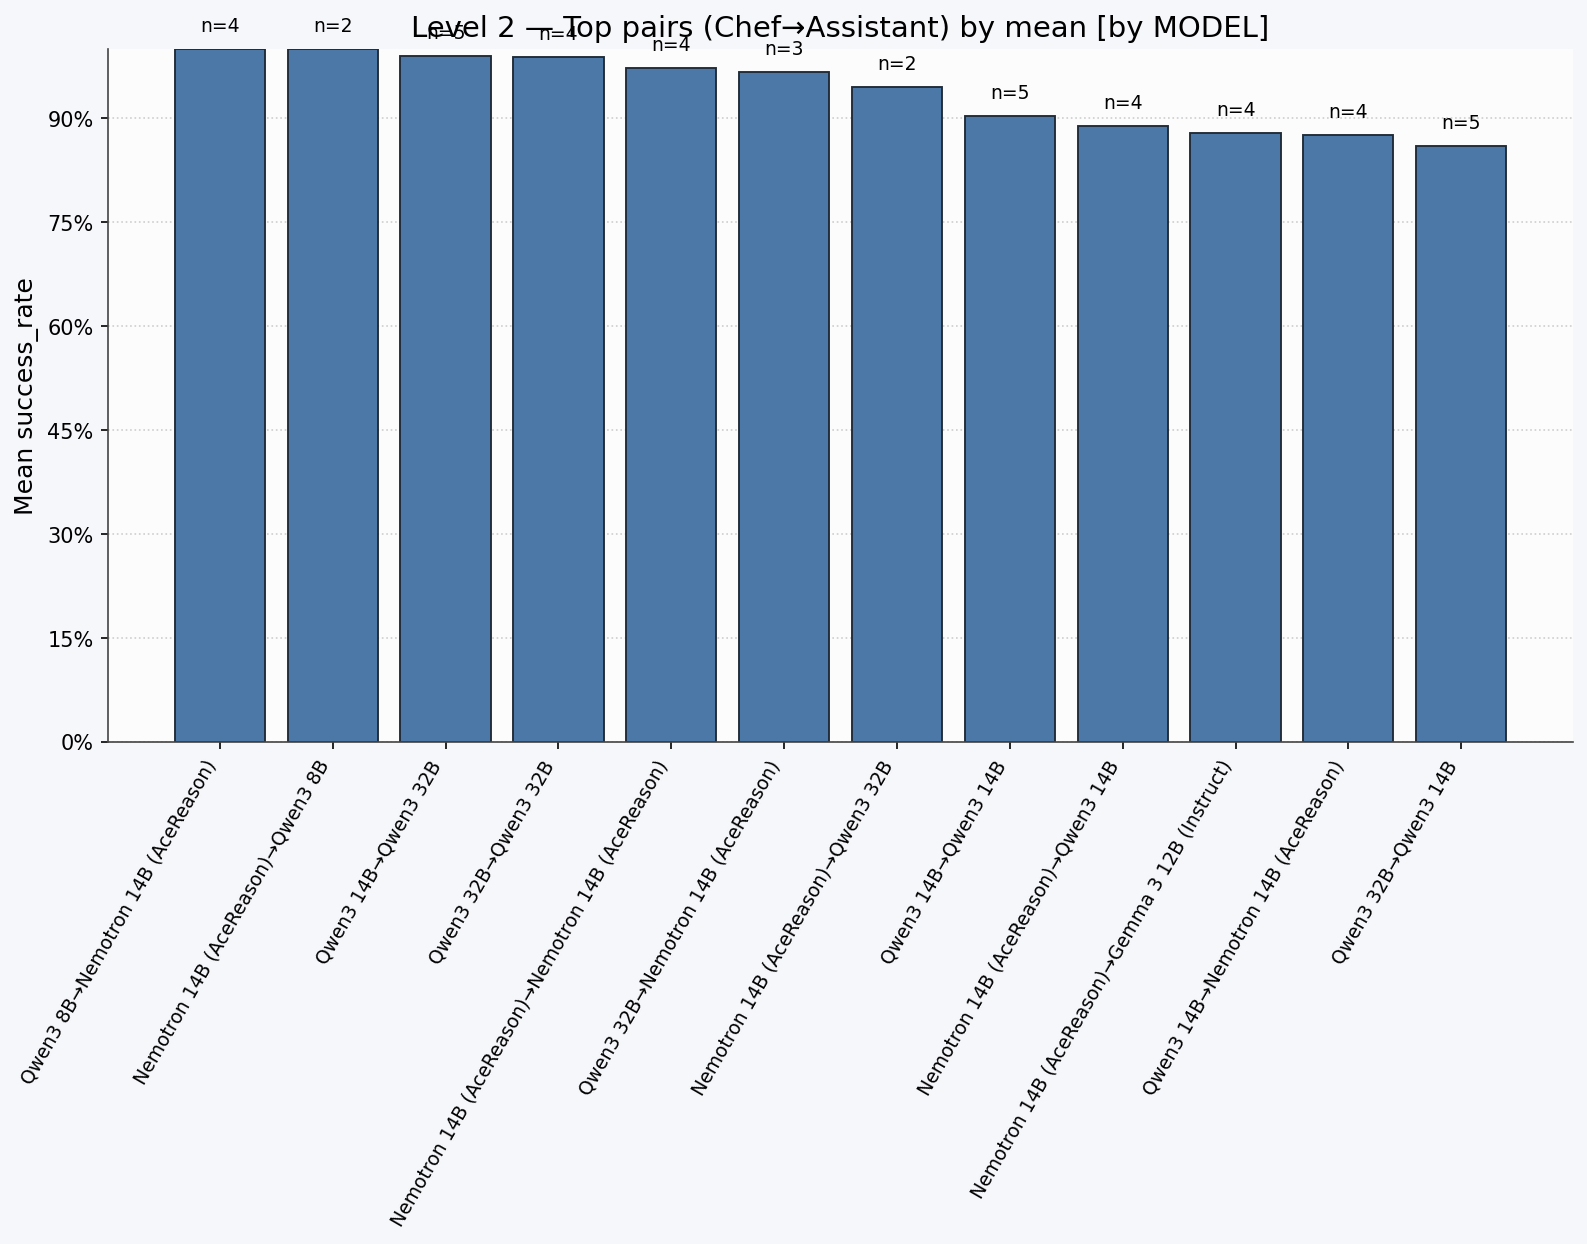

Saved -> ./plots/level_2__top_pairs_by-model_with_self.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_2584/2321982276.py:577: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = plt.cm.get_cmap("Blues", max(10, len(series_Chef_plot)))
/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_2584/2321982276.py:602: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_A = plt.cm.get_cmap("Blues", max(10, len(series_Asst_plot)))


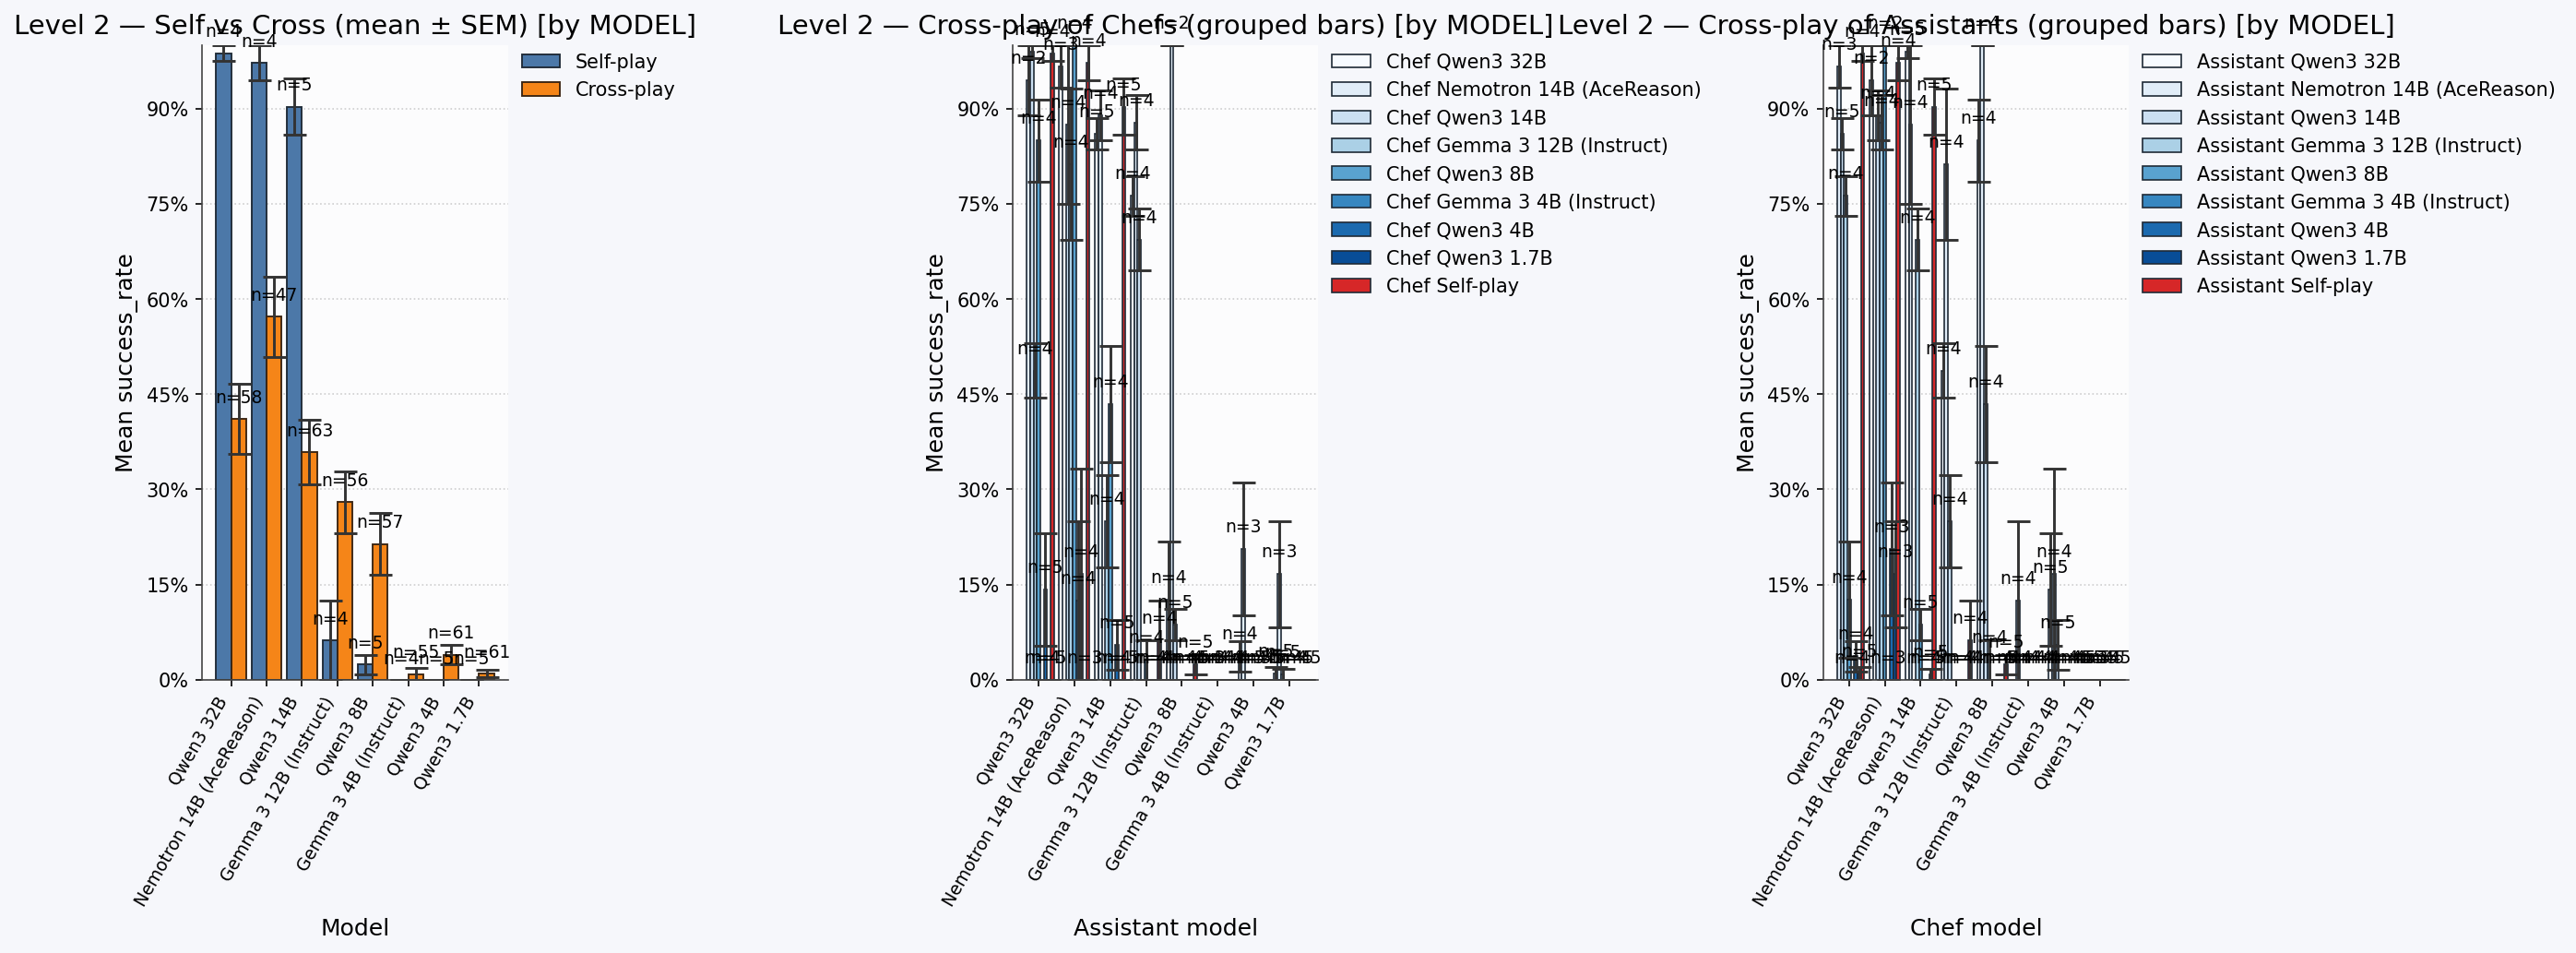

Saved -> ./plots/level_2__composite_bars_by-model.png
[Level 2] Final models used (complete-mix): 8
  Chef models: ['Qwen_Qwen3-32B', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-14B', 'google_gemma-3-12b-it', 'Qwen_Qwen3-8B', 'google_gemma-3-4b-it', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-1.7B']
  Assistant models: ['Qwen_Qwen3-32B', 'nvidia_AceReason-Nemotron-14B', 'Qwen_Qwen3-14B', 'google_gemma-3-12b-it', 'Qwen_Qwen3-8B', 'google_gemma-3-4b-it', 'Qwen_Qwen3-4B', 'Qwen_Qwen3-1.7B']


In [13]:
# NumPy + matplotlib (no pandas)
# Jupyter-friendly Level-2 analysis grouped by *MODEL NAME* (not size)
# Role mapping (agreed):
#   agent_0 = Chef (first model in 'model' string)
#   agent_1 = Assistant (second model in 'model' string)

import os
import csv
import re
import math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

# =================== Config (adjust here if needed) ===================
INPUT_CANDIDATES = [
    "statistics_data_cross-play-data.csv",            # local alt
    "/mnt/data/statistics_data_cross-play-data.csv",  # colab/notebook
]
OUT_DIR = "./plots"
ONLY_LEVEL = 2            # numeric level filter
SUCCESS_COL = 3           # success_rate column index (0-based)

# Mutual-coverage set ("complete-mix"): for every A,B in the set, both A→B and B→A exist
REQUIRE_BIDIRECTIONAL = True
REQUIRE_SELF_FOR_SELECTION = False  # self-play not required to include a model in the set

# Plot behavior / style
VERBOSE_SUMMARY = True
ANNOTATE_COUNTS = True
TOP_PAIRS_COUNT = 12
INCLUDE_SELF_IN_TOP = True
COLORS = {"self": "#4C78A8", "cross": "#F58518"}
SELFPLAY_RED = "#D62728"

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

# =================== New helpers (size-order + pretty names + outside legends) ===================

def order_models_by_size_and_prettify(models, *, descending=True):
    """
    Parameters
    ----------
    models : Iterable[str]
        Raw model identifiers from the CSV (e.g., 'Qwen_Qwen3-8B', 'google_gemma-3-4b-it').
    descending : bool
        If True, larger models first.

    Returns
    -------
    sorted_models : list[str]
        Same identifiers, sorted by parsed size (B). Unknown sizes go to the end.
    pretty_map : dict[str, str]
        Mapping raw_id -> human-friendly name (for axes & legends).
    size_map : dict[str, float]
        Parsed sizes in billions (float('inf') if size not found).
    """
    import re as _re

    def _extract_size_b(s: str) -> float:
        # take the right-most "<number>(.number)?[bB]" as the size in billions
        m = list(_re.finditer(r"(\d+(?:\.\d+)?)\s*[bB](?![a-zA-Z])", s))
        return float(m[-1].group(1)) if m else float('inf')

    def _pretty(s: str) -> str:
        low = s.lower()

        # Qwen family
        if 'qwen3' in low:
            m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
            return f"Qwen3 {m.group(1)}B" if m else "Qwen3"

        # Gemma 3 family
        if 'gemma-3' in low:
            m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
            sz = f"{m.group(1)}B" if m else ""
            return f"Gemma 3 {sz} (Instruct)".strip()

        # Nemotron / AceReason family
        if 'nemotron' in low:
            m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
            sz = f"{m.group(1)}B" if m else ""
            tag = "AceReason" if 'acereason' in low else ""
            return f"Nemotron {sz} {f'({tag})' if tag else ''}".strip()

        # Generic fallback: title-case the second half, keep size if present
        m = re.search(r'(\d+(?:\.\d+)?)\s*[bB]', low)
        sz = f"{m.group(1)}B" if m else ""
        fam = s.split('_', 1)[-1] if '_' in s else s
        fam = re.sub(r'[-_](it|instruct|chat)$', '', fam, flags=re.I)
        fam = fam.replace('-', ' ').replace('_', ' ').title()
        fam = fam.strip()
        return (f"{fam} {sz}").strip()

    sizes = {m: _extract_size_b(m) for m in models}

    def _sort_key(m):
        sz = sizes[m]
        unknown = math.isinf(sz)
        # unknown -> sort after known by using (1, ...)
        if descending:
            return (1 if unknown else 0, -sz if not unknown else 0.0, m.lower())
        else:
            return (1 if unknown else 0, sz if not unknown else float('inf'), m.lower())

    sorted_models = sorted(models, key=_sort_key)
    pretty_map = {m: _pretty(m) for m in sorted_models}
    return sorted_models, pretty_map, sizes


def legend_outside(ax, *, rename_map=None, side="right", ncol=1):
    """Move legend outside the plotting area and optionally rename model labels.
    Call after drawing bars/lines.
    """
    handles, labels = ax.get_legend_handles_labels()
    if rename_map:
        new_labels = []
        for lab in labels:
            if lab.strip().lower().endswith("self-play") or lab.lower() in {"self-play", "cross-play"}:
                new_labels.append(lab)
                continue
            parts = lab.split(" ", 1)
            if len(parts) == 2:
                prefix, raw = parts
                new_labels.append(f"{prefix} {rename_map.get(raw, raw)}")
            else:
                new_labels.append(rename_map.get(lab, lab))
        labels = new_labels

    if side == "right":
        ax.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False,
                  ncol=int(ncol), borderaxespad=0.0)
    elif side == "left":
        ax.legend(handles, labels, bbox_to_anchor=(-0.02, 1), loc="upper right", frameon=False,
                  ncol=int(ncol), borderaxespad=0.0)
    elif side == "top":
        ax.legend(handles, labels, bbox_to_anchor=(0.5, 1.15), loc="upper center", frameon=False,
                  ncol=int(ncol), borderaxespad=0.0)
    else:  # bottom
        ax.legend(handles, labels, bbox_to_anchor=(0.5, -0.15), loc="lower center", frameon=False,
                  ncol=int(ncol), borderaxespad=0.0)


# =================== Helpers (existing) ===================

def find_path(cands):
    for p in cands:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV at any of: {cands}")

# Expect pattern like "Vendor_ModelA-Vsize_Vendor_ModelB-Vsize"
def parse_pair(model_str):
    parts = model_str.split("_")
    if len(parts) >= 4:
        a = parts[0] + "_" + parts[1]  # Chef (agent_0)
        b = parts[2] + "_" + parts[3]  # Assistant (agent_1)
    else:
        mid = len(parts) // 2
        a = "_".join(parts[:mid])
        b = "_".join(parts[mid:])
    return a, b

# For model-name sorting (lexicographic, case-insensitive)
def model_key(name: str):
    return (name.split("_")[0].lower(), name.lower())

# Percent SEM

def sem(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float("nan")
    return float(np.std(x, ddof=1) / np.sqrt(n))

# Cosmetics

def sanitize_token(s):
    import re as _re
    return _re.sub(r"[^A-Za-z0-9._-]+", "_", str(s))

def polish_axes(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor("#FCFCFD")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

def format_as_percent_if_applicable(ax, ymax_est):
    # If success_rate appears to be in [0,1], display as %
    if np.isfinite(ymax_est) and ymax_est <= 1.05:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*100:.0f}%"))
        ax.set_ylim(0, max(1.0, ymax_est))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

def show_and_save(fig, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        from IPython.display import display
        display(fig)
    except Exception:
        plt.show()
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    print("Saved ->", path)

# Grouped-bars utility

def _safe_color_from_map(cmap, i, k):
    if k <= 1:
        t = 0.5
    else:
        t = i / (k - 1)
    return cmap(t)

def plot_grouped_bars(ax, x_labels, series_keys, mean_map, sem_map, n_map,
                      color_map, label_prefix, error_kw, color_for=None,
                      annotate_counts=True):
    x = np.arange(len(x_labels), dtype=float)
    k = max(1, len(series_keys))
    width = min(0.85 / k, 0.28)

    ymax_est = 0.0
    for i, sk in enumerate(series_keys):
        heights = [mean_map[sk].get(lbl, float("nan")) for lbl in x_labels]
        errors  = [sem_map[sk].get(lbl,  float("nan")) for lbl in x_labels]
        counts  = [n_map[sk].get(lbl,    0)             for lbl in x_labels]

        pos = x + (i - (k - 1) / 2.0) * width
        color = color_for(i, sk) if color_for is not None else _safe_color_from_map(color_map, i, k)

        bars = ax.bar(pos, heights, width,
                      yerr=errors,
                      label=f"{label_prefix} {sk}",
                      color=color,
                      edgecolor="#1f2a36",
                      linewidth=0.8,
                      error_kw=error_kw)

        ymin, ymax = ax.get_ylim()
        yrange = ymax - ymin if ymax > ymin else 1.0
        for rect, h, n, e in zip(bars, heights, counts, errors):
            if not np.isfinite(h):
                continue
            ymax_est = max(ymax_est, float(h) + (e if np.isfinite(e) else 0.0))
            if annotate_counts:
                ax.text(rect.get_x() + rect.get_width()/2.0,
                        rect.get_height() + 0.02 * yrange,
                        f"n={n}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x, x_labels, rotation=60, ha="right")
    return ymax_est

# =================== Read CSV (positional schema) ===================

def is_level_two(v):
    s = str(v).strip().lower()
    return s == "2" or s == "2.0" or bool(re.search(r"(?:^|[^0-9])2(?:\.0+)?(?:[^0-9]|$)", s))

csv_path = find_path(INPUT_CANDIDATES)

rows_level2 = []  # (chef_model, asst_model, success_rate)
pairs_present_dir = set()
models_all = set()
self_present = defaultdict(bool)

with open(csv_path, newline="", encoding="utf-8") as f:
    rd = csv.reader(f)
    header = next(rd, None)  # skip header
    for row in rd:
        if not row or len(row) < 4:
            continue
        model_str = row[0].strip()
        level_raw = row[2].strip()  # numeric level lives here in this file
        if not is_level_two(level_raw):
            continue

        # success rate from configured column
        sr = None
        try:
            sr = float(row[SUCCESS_COL])
        except Exception:
            # last-numeric fallback
            for tok in reversed(row):
                try:
                    sr = float(tok)
                    break
                except Exception:
                    continue
        if sr is None:
            continue

        a_model, b_model = parse_pair(model_str)  # full model identifiers (include sizes)
        if not a_model or not b_model:
            continue

        models_all.update([a_model, b_model])
        pairs_present_dir.add((a_model, b_model))
        if a_model == b_model:
            self_present[a_model] = True

        rows_level2.append((a_model, b_model, sr))

if not models_all:
    raise RuntimeError("No Level 2 rows found (by-model parsing). Check CSV format and SUCCESS_COL.")

if VERBOSE_SUMMARY:
    print(f"[Level 2] total usable rows: {len(rows_level2)}")
    print(f"[Level 2] models seen: {len(models_all)} ->", sorted(models_all, key=model_key))
    print(f"[Level 2] self-play present for: {[m for m,v in self_present.items() if v]}")

# =================== Clique (complete-mix) over MODELS ===================

def build_mutual_graph(pairs_present, models):
    neighbors = {m: set() for m in models}
    for a in models:
        for b in models:
            if a == b:
                continue
            if (a, b) in pairs_present and (b, a) in pairs_present:
                neighbors[a].add(b)
    return neighbors


def is_clique(nodes, neighbors, require_self=False, self_present=None):
    nodes = list(nodes)
    for i in range(len(nodes)):
        for j in range(i+1, len(nodes)):
            a, b = nodes[i], nodes[j]
            if b not in neighbors.get(a, set()) or a not in neighbors.get(b, set()):
                return False
    if require_self and self_present is not None:
        for m in nodes:
            if not self_present.get(m, False):
                return False
    return True


def largest_complete_mix_set(neighbors, require_self=False, self_present=None):
    from itertools import combinations
    models = sorted(neighbors.keys(), key=model_key)
    n = len(models)
    for k in range(n, 0, -1):
        found = []
        for combo in combinations(models, k):
            if is_clique(combo, neighbors, require_self=require_self, self_present=self_present):
                found.append(list(combo))
        if found:
            # Prefer combos with more self-play present, then lexicographic
            if not require_self and self_present is not None:
                found.sort(key=lambda lst: (sum(1 for m in lst if self_present.get(m, False)),
                                            [m.lower() for m in lst]), reverse=True)
            return found[0]
    return []

neighbors = build_mutual_graph(pairs_present_dir, models_all)
selected_models = largest_complete_mix_set(neighbors,
                                           require_self=REQUIRE_SELF_FOR_SELECTION,
                                           self_present=self_present)
if not selected_models:
    selected_models = sorted(models_all, key=model_key)  # fallback

if VERBOSE_SUMMARY:
    print(f"[Level 2] selected 'complete-mix' MODELS: {selected_models}")

# =================== Aggregate restricted to selected models ===================
level_key = "2"  # string key for dicts
buckets_by_model = defaultdict(list)  # (level, model, 'self'/'cross') -> list[success_rate]
cross_matrix = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
chef_models_by_level = defaultdict(set)
assistant_models_by_level = defaultdict(set)
models_seen = set()

selected_set = set(selected_models)
for a_model, b_model, sr in rows_level2:
    if a_model not in selected_set or b_model not in selected_set:
        continue
    models_seen.update([a_model, b_model])

    if a_model == b_model:
        buckets_by_model[(level_key, a_model, "self")].append(sr)
    else:
        buckets_by_model[(level_key, a_model, "cross")].append(sr)
        buckets_by_model[(level_key, b_model, "cross")].append(sr)
        cross_matrix[level_key][a_model][b_model].append(sr)
        chef_models_by_level[level_key].add(a_model)
        assistant_models_by_level[level_key].add(b_model)

# Global (all-role) model list, size-ordered + pretty labels
models_sorted, PRETTY_MAP, _SIZE_MAP = order_models_by_size_and_prettify(models_seen, descending=True)

# Role-aware maps

def build_role_aware_maps(level, selected_models, cross_matrix, buckets_by_model,
                          chef_models_by_level, assistant_models_by_level):
    chef_models = sorted([m for m in chef_models_by_level[level] if m in selected_models], key=model_key)
    assistant_models = sorted([m for m in assistant_models_by_level[level] if m in selected_models], key=model_key)

    means_Chef, sems_Chef, ns_Chef = {}, {}, {}
    for cm in chef_models:
        means_Chef[cm], sems_Chef[cm], ns_Chef[cm] = {}, {}, {}
        for am in assistant_models:
            vals = cross_matrix[level][cm].get(am, [])
            m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
            means_Chef[cm][am] = m; sems_Chef[cm][am] = s; ns_Chef[cm][am] = n

    SELF_KEY = "Self-play"
    means_Chef[SELF_KEY], sems_Chef[SELF_KEY], ns_Chef[SELF_KEY] = {}, {}, {}
    for am in assistant_models:
        vals = buckets_by_model.get((level, am, "self"), [])
        m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
        means_Chef[SELF_KEY][am] = m; sems_Chef[SELF_KEY][am] = s; ns_Chef[SELF_KEY][am] = n
    series_Chef = chef_models + [SELF_KEY]

    means_Asst, sems_Asst, ns_Asst = {}, {}, {}
    for am in assistant_models:
        means_Asst[am], sems_Asst[am], ns_Asst[am] = {}, {}, {}
        for cm in chef_models:
            vals = cross_matrix[level][cm].get(am, [])
            m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
            means_Asst[am][cm] = m; sems_Asst[am][cm] = s; ns_Asst[am][cm] = n

    means_Asst[SELF_KEY], sems_Asst[SELF_KEY], ns_Asst[SELF_KEY] = {}, {}, {}
    for cm in chef_models:
        vals = buckets_by_model.get((level, cm, "self"), [])
        m, s, n = (float("nan"), float("nan"), 0) if len(vals)==0 else (float(np.mean(vals)), sem(vals), len(vals))
        means_Asst[SELF_KEY][cm] = m; sems_Asst[SELF_KEY][cm] = s; ns_Asst[SELF_KEY][cm] = n
    series_Asst = assistant_models + ["Self-play"]

    return (chef_models, assistant_models,
            means_Chef, sems_Chef, ns_Chef,
            means_Asst, sems_Asst, ns_Asst,
            series_Chef, series_Asst)

# Self vs Cross vectors

def build_self_vs_cross_vectors(level, models_sorted, buckets_by_model):
    means_self_all, sems_self_all, n_self_all = [], [], []
    means_cross_all, sems_cross_all, n_cross_all = [], [], []
    for m in models_sorted:
        xs = np.array(buckets_by_model.get((level, m, "self"), []), dtype=float)
        xc = np.array(buckets_by_model.get((level, m, "cross"), []), dtype=float)
        m_s = float(np.mean(xs)) if xs.size else float("nan")
        m_c = float(np.mean(xc)) if xc.size else float("nan")
        means_self_all.append(m_s); sems_self_all.append(sem(xs) if xs.size else float("nan")); n_self_all.append(int(xs.size))
        means_cross_all.append(m_c); sems_cross_all.append(sem(xc) if xc.size else float("nan")); n_cross_all.append(int(xc.size))
    return (means_self_all, sems_self_all, n_self_all,
            means_cross_all, sems_cross_all, n_cross_all)

# Top pairs

def build_top_pairs(level, models_allowed, cross_matrix, buckets_by_model, include_self=True):
    pairs = []
    chefs = sorted(models_allowed, key=model_key)
    assts = sorted(models_allowed, key=model_key)
    for cm in chefs:
        for am in assts:
            if cm == am:
                continue
            vals = cross_matrix[level][cm].get(am, [])
            if vals:
                m = float(np.mean(vals)); n = len(vals)
                pairs.append((m, math.log(n + 1.0), n, cm, am))
    if include_self:
        for m in sorted(models_allowed, key=model_key):
            vals = buckets_by_model.get((level, m, "self"), [])
            if vals:
                pairs.append((float(np.mean(vals)), math.log(len(vals) + 1.0), len(vals), m, m))
    return pairs

# =================== Build maps & vectors ===================
(chef_models, assistant_models,
 means_Chef, sems_Chef, ns_Chef,
 means_Asst, sems_Asst, ns_Asst,
 series_Chef, series_Asst) = build_role_aware_maps(level_key, set(selected_models),
                                                   cross_matrix, buckets_by_model,
                                                   chef_models_by_level, assistant_models_by_level)

# Reorder role lists by size for plotting
chef_models_size, _, _ = order_models_by_size_and_prettify(chef_models, descending=True)
assistant_models_size, _, _ = order_models_by_size_and_prettify(assistant_models, descending=True)

(means_self_all, sems_self_all, n_self_all,
 means_cross_all, sems_cross_all, n_cross_all) = build_self_vs_cross_vectors(level_key, models_sorted, buckets_by_model)

# =================== Top pairs (Level 2) ===================
pairs = build_top_pairs(level_key, set(models_sorted), cross_matrix, buckets_by_model, include_self=INCLUDE_SELF_IN_TOP)
if pairs:
    pairs.sort(key=lambda t: (t[0], t[1]), reverse=True)
    top = pairs[:max(1, TOP_PAIRS_COUNT)]
    labels = [f"{PRETTY_MAP.get(cm, cm)}\u2192{PRETTY_MAP.get(am, am)}" for (_, _, _, cm, am) in top]
    means  = [m for (m, _, _, _, _) in top]
    counts = [n for (_, _, n, _, _) in top]

    fig_tp = plt.figure(figsize=(max(12, 0.55*len(top) + 6), 6))
    ax_tp  = fig_tp.add_subplot(111); fig_tp.patch.set_facecolor("#F6F7FB")

    x = np.arange(len(top))
    bars = ax_tp.bar(x, means, edgecolor="#1f2a36", linewidth=0.9, color=COLORS["self"])
    ax_tp.set_xticks(x, labels, rotation=60, ha="right")
    ax_tp.set_ylabel("Mean success_rate")
    ax_tp.set_title(f"Level {level_key} — Top pairs (Chef→Assistant) by mean [by MODEL]")
    polish_axes(ax_tp)

    ymax_est = float(max(means)) if means else float("nan")
    format_as_percent_if_applicable(ax_tp, ymax_est)

    ymin, ymax = ax_tp.get_ylim(); yrange = ymax - ymin
    if ANNOTATE_COUNTS:
        for rect, n in zip(bars, counts):
            h = rect.get_height()
            if np.isfinite(h):
                ax_tp.text(rect.get_x() + rect.get_width()/2.0,
                           h + 0.02*yrange,
                           f"n={n}",
                           ha="center", va="bottom", fontsize=9)

    out_png = os.path.join(OUT_DIR, f"level_{sanitize_token(level_key)}__top_pairs_by-model{'_with_self' if INCLUDE_SELF_IN_TOP else ''}.png")
    show_and_save(fig_tp, out_png)


# =================== Composite 1x3 (Level 2, by MODEL) ===================
error_kw_common = dict(ecolor="#333333", linewidth=1.4, capsize=6, capthick=1.4)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.patch.set_facecolor("#F6F7FB")

# Panel (1): Self vs Cross — mean ± SEM by MODEL
ax = axes[0]
x = np.arange(len(models_sorted))
width = 0.42

a = np.nan_to_num(np.array(means_self_all),  nan=0.0) + np.nan_to_num(np.array(sems_self_all),  nan=0.0)
b = np.nan_to_num(np.array(means_cross_all), nan=0.0) + np.nan_to_num(np.array(sems_cross_all), nan=0.0)
ymax_est1 = float(max(np.max(a) if a.size else 0.0, np.max(b) if b.size else 0.0))

b1 = ax.bar(x - width/2, means_self_all,  width, yerr=sems_self_all,  label="Self-play",
            color=COLORS["self"],  edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw_common)
b2 = ax.bar(x + width/2, means_cross_all, width, yerr=sems_cross_all, label="Cross-play",
            color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw_common)

ax.set_xticks(x)
ax.set_xticklabels([PRETTY_MAP.get(m, m) for m in models_sorted], rotation=60, ha="right")
ax.set_xlabel("Model")
ax.set_ylabel("Mean success_rate")
ax.set_title(f"Level {level_key} — Self vs Cross (mean ± SEM) [by MODEL]")
polish_axes(ax)
format_as_percent_if_applicable(ax, ymax_est1)
legend_outside(ax, side="right", ncol=1)  # move legend out

ymin, ymax = ax.get_ylim(); yrange = ymax - ymin
if ANNOTATE_COUNTS:
    for rect, n in zip(b1, n_self_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)
    for rect, n in zip(b2, n_cross_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)

# Panel (2): Cross-play of Chefs — x=Assistant MODEL, series=Chef MODEL + Self (red)
ax = axes[1]
series_Chef_plot = list(chef_models_size) + ["Self-play"]
cmap_C = plt.cm.get_cmap("Blues", max(10, len(series_Chef_plot)))
ymax_est2 = plot_grouped_bars(ax,
                              x_labels=assistant_models_size,
                              series_keys=series_Chef_plot,
                              mean_map=means_Chef,
                              sem_map=sems_Chef,
                              n_map=ns_Chef,
                              color_map=cmap_C,
                              label_prefix="Chef",
                              error_kw=error_kw_common,
                              color_for=lambda i, sk: SELFPLAY_RED if sk == "Self-play" else _safe_color_from_map(cmap_C, i, len(series_Chef_plot)),
                              annotate_counts=ANNOTATE_COUNTS)
ax.set_xlabel("Assistant model")
ax.set_ylabel("Mean success_rate")
ax.set_title(f"Level {level_key} — Cross-play of Chefs (grouped bars) [by MODEL]")
polish_axes(ax)
format_as_percent_if_applicable(ax, ymax_est2 if np.isfinite(ymax_est2) else np.nan)
# Replace raw x tick labels by pretty names
ax.set_xticks(np.arange(len(assistant_models_size)))
ax.set_xticklabels([PRETTY_MAP.get(m, m) for m in assistant_models_size], rotation=60, ha="right")
legend_outside(ax, rename_map=PRETTY_MAP, side="right", ncol=1)

# Panel (3): Cross-play of Assistants — x=Chef MODEL, series=Assistant MODEL + Self (red)
ax = axes[2]
series_Asst_plot = list(assistant_models_size) + ["Self-play"]
cmap_A = plt.cm.get_cmap("Blues", max(10, len(series_Asst_plot)))
ymax_est3 = plot_grouped_bars(ax,
                              x_labels=chef_models_size,
                              series_keys=series_Asst_plot,
                              mean_map=means_Asst,
                              sem_map=sems_Asst,
                              n_map=ns_Asst,
                              color_map=cmap_A,
                              label_prefix="Assistant",
                              error_kw=error_kw_common,
                              color_for=lambda i, sk: SELFPLAY_RED if sk == "Self-play" else _safe_color_from_map(cmap_A, i, len(series_Asst_plot)),
                              annotate_counts=ANNOTATE_COUNTS)
ax.set_xlabel("Chef model")
ax.set_ylabel("Mean success_rate")
ax.set_title(f"Level {level_key} — Cross-play of Assistants (grouped bars) [by MODEL]")
polish_axes(ax)
format_as_percent_if_applicable(ax, ymax_est3 if np.isfinite(ymax_est3) else np.nan)
# Replace raw x tick labels by pretty names
ax.set_xticks(np.arange(len(chef_models_size)))
ax.set_xticklabels([PRETTY_MAP.get(m, m) for m in chef_models_size], rotation=60, ha="right")
legend_outside(ax, rename_map=PRETTY_MAP, side="right", ncol=1)

# Reserve right margin for legends
fig.tight_layout(rect=[0, 0, 0.82, 1])
out_png = os.path.join(OUT_DIR, f"level_{sanitize_token(level_key)}__composite_bars_by-model.png")
show_and_save(fig, out_png)

if VERBOSE_SUMMARY:
    print(f"[Level {level_key}] Final models used (complete-mix): {len(models_sorted)}")
    print("  Chef models:", chef_models_size)
    print("  Assistant models:", assistant_models_size)
